In [1]:
from CASP16_NA_assessment import *
# global (capatalized variables) are defined in there
%matplotlib inline


# this encompasses getting sets of interactions from each model and comparing these sets
# eg base-pairs or A-minor interactions
# this is not scored in analysis because DNA annotations differ from RNA
interactions_not_scores = ['D1273']

TARGETS = MONOMER_TARGETS_TO_SCORETEMP
[TARGETS.remove(target) for target in interactions_not_scores]
print(len(TARGETS)) 

print(len(TEMPLATE_TARGETS),len(NO_TEMPLATE_TARGETS),len(MSA_TARGETS),len(NO_MSA_TARGETS))

35
19 18 23 16


## Read inputs motifs

In [2]:
# Read motif information
natives = pd.read_csv('../raw_scores/motif/sets/native_motif_data.csv')
predicted = pd.read_csv('../raw_scores/motif/sets/predicted_motif_data.csv')

predicted['base_name'] = predicted.file_name.apply(lambda x: x.split('-')[1] if 'rna_motif' in x else x)
predicted['target'] = predicted.base_name.apply(lambda x: x.split('TS')[0] if 'TS' in x else x.split('LG')[0])
# see analyssi below: some LG and TS have different results, so lets say group is inclusive of TS or LG
predicted['group'] = predicted.base_name.apply(lambda x: x.split('_')[-2].split('TS')[1] if 'TS' in x else x.split('_')[-2].split('LG')[1])
predicted['model'] = predicted.base_name.apply(lambda x: x.split('_')[-1].split('.')[0])

# checks
print(predicted.target.unique())
print(predicted.group.unique())
print(predicted.model.unique())
duplicates = predicted.groupby(['target', 'group', 'model'])['file_name'].nunique()
duplicates = duplicates[duplicates != 1]
print(duplicates) # now empty because, based on analysis LG and TS can have different motifs

print(predicted.head())

# create dictionary of native motif
# dict[motif][target] = list of native, list of motifs in native, list of residues in motif
native_motifs = {}
native_motifs_o = {}
natives['target'] = natives.file_name.str[10:-7].apply(lambda x: x.split('_')[0] if '_' in x else x)
na_tar_name = {'R1283v2':'R1283v2o','R1283v3':'R1283v3o'}
natives['target'] = natives.target.apply(lambda x: na_tar_name[x] if x in na_tar_name else x)
for motif, motif_df in natives.groupby('motif_type'):
    native_motifs[motif] = {}
    native_motifs_o[motif] = {}
    if motif == 'A_MINOR':
        native_motifs['DOCKED_A'] = {}
        native_motifs_o['DOCKED_A'] = {}
    if motif == 'INTERCALATED_T_LOOP':
        native_motifs['INTERCALATED_NT'] = {}
        native_motifs_o['INTERCALATED_NT'] = {}
    for target, target_df in motif_df.groupby('target'):
        if 'o' in target or 'M' in target:
            
            native_motifs_o[motif][target[:-1]] = []
            if motif == 'A_MINOR':
                native_motifs_o['DOCKED_A'][target[:-1]] = []
            if motif == 'INTERCALATED_T_LOOP':
                native_motifs_o['INTERCALATED_NT'][target[:-1]] = []
            for file, df in target_df.groupby('file_name'):
                motif_list = df.residues.apply(get_residues_from_rosetta).to_list()
                native_motifs_o[motif][target[:-1]].append(motif_list)
                if motif == 'A_MINOR':
                    native_motifs_o['DOCKED_A'][target[:-1]].append([x[:1] for x in motif_list])
                if motif == 'INTERCALATED_T_LOOP':
                    native_motifs_o['INTERCALATED_NT'][target[:-1]].append([x[-1:] for x in motif_list])
        else:
            native_motifs[motif][target] = []
            if motif == 'A_MINOR':
                native_motifs['DOCKED_A'][target] = []
            if motif == 'INTERCALATED_T_LOOP':
                native_motifs['INTERCALATED_NT'][target] = []
            for file, df in target_df.groupby('file_name'):
                motif_list = df.residues.apply(get_residues_from_rosetta).to_list()
                native_motifs[motif][target].append(motif_list)
                if motif == 'A_MINOR':
                    native_motifs['DOCKED_A'][target].append([x[:1] for x in motif_list])
                if motif == 'INTERCALATED_T_LOOP':
                    native_motifs['INTERCALATED_NT'][target].append([x[-1:] for x in motif_list])
# need to fill in all native_motifs

multimer_predicted = predicted[predicted.file_name.str.contains('o.std|M|o.pdb.std')].copy()
multimer_predicted = multimer_predicted[multimer_predicted.target.isin( MULTIMER_TARGETS )].reset_index()

monomer_predicted = predicted[~predicted.file_name.str.contains('o.std|M|o.pdb.std')].copy()
monomer_predicted = monomer_predicted[monomer_predicted.target.isin(MONOMER_TARGETS_TO_SCORETEMP)].reset_index()

def get_if_multi_chains_motif(residues):
    ress = residues.split('_')
    chains = set([x.split('-')[1].rsplit(':',2)[0] for x in ress])
    return len(chains)>1

def get_chain_rna_motf(residue_list, chains=set()):
    if isinstance(residue_list, list) or isinstance(residue_list, set):
        for res in residue_list:
            chains = get_chains(res, chains) 
    else:
        chain_identifier = residue_list.split('-')[1].rsplit(':',2)[0]  # Take everything before the last colon
        chains.add(chain_identifier) 
    return chains


interface_predictions = multimer_predicted[multimer_predicted.residues.apply(get_if_multi_chains_motif)]

A_minors = monomer_predicted[monomer_predicted.motif_type=='A_MINOR'].copy()
A_minors['motif_type'] = 'DOCKED_A'
A_minors['residues'] = A_minors.residues.apply(lambda res: res.split('_')[0])

int_tloop = monomer_predicted[monomer_predicted.motif_type=='INTERCALATED_T_LOOP'].copy()
int_tloop['motif_type'] = 'INTERCALATED_NT'
int_tloop['residues'] = int_tloop.residues.apply(lambda res: res.split('_')[-1])

monomer_predicted = pd.concat([monomer_predicted,A_minors,int_tloop])
monomer_predicted.tail()

A_minors = interface_predictions[interface_predictions.motif_type=='A_MINOR'].copy()
A_minors['motif_type'] = 'DOCKED_A'
A_minors['residues'] = A_minors.residues.apply(lambda res: res.split('_')[0])

int_tloop = interface_predictions[interface_predictions.motif_type=='INTERCALATED_T_LOOP'].copy()
int_tloop['motif_type'] = 'INTERCALATED_NT'
int_tloop['residues'] = int_tloop.residues.apply(lambda res: res.split('_')[-1])

interface_predictions = pd.concat([interface_predictions,A_minors,int_tloop])
interface_predictions.tail()

def get_multichain_native(motif_dict):
    motif_dict = motif_dict.copy()
    for motif,targ_dict in motif_dict.items():
        for targ,residues in targ_dict.items():
            new_list = []
            for motif_list in residues:
                new_list.append([])
                #res_added = []
                for ress in motif_list:
                    chains = get_chains(ress,set())
                    
                    if len(chains)>1: #and get_residue_numbers(ress) not in res_added:
                        new_list[-1].append(ress)
                        #res_added.append(get_residue_numbers(ress))
            motif_dict[motif][targ] = new_list
    return motif_dict
get_multichain_native(native_motifs_o)

# multichain delete our A docked
for motif, motif_dict in native_motifs_o.items():
    for target, res_lists in motif_dict.items():
        if motif == 'A_MINOR':
            for res_list in res_lists:
                native_motifs_o['DOCKED_A'][target].append([x[:1] for x in res_list])
        if motif == 'INTERCALATED_T_LOOP':
            for res_list in res_lists:
                native_motifs_o['INTERCALATED_NT'][target].append([x[-1:] for x in res_list])
print(native_motifs_o)


['R0250' 'R1283v1' 'R1241' 'R1293' 'R1288' 'R1261' 'R1255' 'R1252' 'R1203'
 'R0254' 'R1221s3' 'R1286' 'R1251' 'R1262' 'R1296' 'R1264' 'R1260' 'R1250'
 'R1291' 'R1211' 'R1224s3' 'R1209' 'R1212' 'R1283v3' 'R1253v2' 'R1253v1'
 'R1289' 'M1212' 'R1254' 'R1242' 'R1283v2' 'R1224s2' 'R1248' 'R1285'
 'R1281' 'R1256' 'R1221s2' 'R1271' 'R0281' 'R0290' 'R1290' 'R1205' 'R0283'
 'R0252' 'R1263' 'R0251' 'R0285' 'R0253']
['462' '006' '456' '208' '028' '156' '183' '189' '448' '110' '304' '450'
 '306' '425' '231' '262' '481' '294' '165' '241' '317' '435' '369' '272'
 '338' '091' '167' '159' '286' '094' '408' '267' '063' '235' '052' '325'
 '417' '033' '358' '238' '143' '439' '298' '261' '051' '307' '020' '464'
 '345' '055' '044' '423' '227' '207' '026' '447' '147' '403' '400' '319'
 '331' '276' '471' '367']
['4o' '3' '1' '4' '2' '5' '3o' '2o' '1o' '5o' '0' '6']
target  group  model
R1261   091    1        2
               2        2
               3        2
               4        2
               5    

In [3]:
def get_table_format_nochain(res_lists):
    rt_st = ''
    current_res = []
    for i,res_list in enumerate(res_lists):
        to_add = ''
        
        for ress in res_list:
            to_add += " ".join([t.split(':')[-1] for t in ress])
            to_add += '\n'
        if to_add in current_res:
            continue
        if i>0:
            rt_st+='-------\n'
        current_res.append(to_add)
        rt_st += to_add
            
        
    return rt_st[:-1]

def get_table_format(res_lists):
    rt_st = ''
    current_res = []
    for i,res_list in enumerate(res_lists):
        to_add = ''
        
        for ress in res_list:
            to_add += " ".join(ress)
            to_add += '\n'
        if to_add in current_res:
            continue
        if i>0:
            rt_st+='-------\n'
        current_res.append(to_add)
        rt_st += to_add
            
        
    return rt_st[:-1]
temp = []
for x in native_motifs.keys():
    temp.append(pd.Series(native_motifs[x],name=x).apply(get_table_format_nochain))
                #.T.rename(columns={'0':x}).apply(get_table_format,axis=1))
#pd.concat(temp,axis=1,join='outer').sort_index().to_csv('temp2.csv')
temp = []
for x in native_motifs_o.keys():
    temp.append(pd.Series(native_motifs_o[x],name=x).apply(get_table_format))
                #.T.rename(columns={'0':x}).apply(get_table_format,axis=1))
#pd.concat(temp,axis=1,join='outer').sort_index().to_csv('temp3.csv')

In [4]:
monomer_predicted['motif_type'] = monomer_predicted['motif_type'].map(MOTIF_TYPES)
interface_predictions['motif_type'] = interface_predictions['motif_type'].map(MOTIF_TYPES)
native_motifs = {MOTIF_TYPES[x]:y for x,y in native_motifs.items()}
native_motifs_o = {MOTIF_TYPES[x]:y for x,y in native_motifs_o.items()}

## generate scores

In [13]:
def _max_with_nan_list(x):
    if x == []:
        return np.nan
    return max(x) if not any([i!=i for i in x]) else np.nan

scores_monomer_motif = []
for (motif,target),df in monomer_predicted.groupby(['motif_type','target']):
    if target not in native_motifs[motif]:
        native_motifs[motif][target] = []
        
    native = native_motifs[motif][target]
    scores_monomer_motif.append( df.groupby(['file_name','motif_type','target','group','model']).apply(
        lambda rr: compare_set_lists(native,[get_residues_from_rosetta(l) for l in rr.residues.to_list()],
                                     target, #rr.target.unique()[0],
                        zero_division = 0, 
                        both_none_value = np.nan, 
                        return_recall=False,return_precision=False )).reset_index())

scores_monomer_motif = pd.concat(scores_monomer_motif).rename(columns={0:'F1_Scores'})
scores_monomer_motif['F1'] = scores_monomer_motif.F1_Scores.apply(_max_with_nan_list)

scores_multimer_motif = []
for (motif,target),df in interface_predictions.groupby(['motif_type','target']):
    if target not in native_motifs_o[motif]:
        native_motifs_o[motif][target] = []
        
    native = native_motifs_o[motif][target]
    scores_multimer_motif.append( df.groupby(['file_name','motif_type','target','group','model']).apply(
        lambda rr: compare_set_lists(native,[get_residues_from_rosetta(l) for l in rr.residues.to_list()],
                                     target, #rr.target.unique()[0],
                        zero_division = 0, 
                        both_none_value = np.nan, 
                        return_recall=False,return_precision=False )).reset_index())
scores_multimer_motif = pd.concat(scores_multimer_motif).rename(columns={0:'F1_Scores'})
scores_multimer_motif['F1'] = scores_multimer_motif.F1_Scores.apply(_max_with_nan_list)

C:\Users\racha\AppData\Local\Temp\ipykernel_23024\3590908582.py:12: DeprecationWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  scores_monomer_motif.append( df.groupby(['file_name','motif_type','target','group','model']).apply(
C:\Users\racha\AppData\Local\Temp\ipykernel_23024\3590908582.py:12: DeprecationWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  scores_monomer_motif.append( df.groupby(['file_name','motif_type','target','group'

In [14]:
scores_multimer_motif.F1.unique()

array([0.        ,        nan, 0.11764706, 0.44444444, 0.25      ,
       0.2       , 0.57142857, 0.4       , 0.13333333, 0.25      ,
       0.18181818, 0.5       , 0.33333333, 0.4       , 0.33333333,
       0.8       , 0.44444444, 0.28571429, 1.        ])

In [15]:
scores_multimer_motif[scores_multimer_motif.F1>0].motif_type.unique()

array(['Docked A'], dtype=object)

In [16]:
scores_multimer_motif[scores_multimer_motif.F1>0].target.unique()

array(['R1251', 'R1254', 'R1283v2'], dtype=object)

In [17]:
no_motif_models = pd.read_csv('../raw_scores/motif/sets/predicted_no_motifs.csv').file_name.apply(lambda s: s.split('rna_motif-')[-1].split('.stdout')[0])
no_motif_models
oligo = (no_motif_models.str[0]=='M' ) | (no_motif_models.str.contains('o.'))
multimer_no_moitf = no_motif_models[oligo].copy()
monomer_no_motif = no_motif_models[~oligo].copy()

In [18]:

native_motif_counts = {}
for motif,motif_lists in native_motifs.items():
    native_motif_counts[motif] = []
    for target, t_list in motif_lists.items():
        if not (not t_list or all(not item for item in t_list)) and target in MONOMER_TARGETS_TO_SCORETEMP:
            native_motif_counts[motif].append(target)
native_motif_counts

rows = []
for model in monomer_no_motif:
    target,mm = model.split('TS') if 'TS' in model else model.split('LG')
    group, model = mm.split('_')
    for motif in MOTIF_TYPES.values():
        if target in native_motif_counts[motif]:
            rows.append( {'target':target,'group':group,'model':model,'motif_type':motif,
                  'F1': 0})
        else:
            rows.append( {'target':target,'group':group,'model':model,'motif_type':motif,
                  'F1': np.nan})
scores_monomer_motif = pd.concat([scores_monomer_motif, pd.DataFrame(rows)], ignore_index=True)
rows = []

for (group,target),working_df in scores_monomer_motif.groupby(['group','target']):
    extra_motifs = [m for m in MOTIF_TYPES.values() if m not in working_df.motif_type.to_list()]
    for motif in extra_motifs:
        if target in native_motif_counts[motif]:
            rows.append( {'target':target,'group':group,'motif_type':motif,
                  'F1': 0})
        else:
            rows.append( {'target':target,'group':group,'motif_type':motif,
                  'F1': np.nan})
scores_monomer_motif = pd.concat([scores_monomer_motif, pd.DataFrame(rows)], ignore_index=True)
scores_monomer_motif['group'] = scores_monomer_motif.group.map(GR_CODE_TO_NAME_SERVER)
scores_monomer_motif

,file_name,motif_type,target,group,model,F1_Scores,F1
0,rna_motif-R1205TS052_2.stdout,A-minor,R1205,Yang-Server - S 052,2,[],NaN
1,rna_motif-R1205TS189_2.stdout,A-minor,R1205,LCBio - 189,2,[],NaN
2,rna_motif-R1205TS338_3.stdout,A-minor,R1205,GeneSilico - 338,3,[],NaN
3,rna_motif-R1205TS358_3.stdout,A-minor,R1205,PerezLab_Gators - 358,3,[],NaN
4,rna_motif-R1205TS358_4.stdout,A-minor,R1205,PerezLab_Gators - 358,4,[],NaN
...,...,...,...,...,...,...,...
57367,NaN,Bulged-G,R1293,Vfold - 481,NaN,NaN,NaN
57368,NaN,A-minor,R1293,Vfold - 481,NaN,NaN,NaN
57369,NaN,Tandem-GA-Sheared,R1293,Vfold - 481,NaN,NaN,NaN
57370,NaN,Intercalated nucleotide,R1293,Vfold - 481,NaN,NaN,NaN


In [19]:
scores_monomer_motif.F1.max()

1.0

In [20]:
native_motif_countso = {}
for motif,motif_lists in native_motifs_o.items():
    native_motif_countso[motif] = []
    for target, t_list in motif_lists.items():
        if not (not t_list or all(not item for item in t_list)) and target in MULTIMER_TARGETS:
        #(len(t_list)>0 or (len(t_list)==1 and len(t_list[0]>0))) and target in MULTIMER_TARGETS:
            native_motif_countso[motif].append(target)

rows = []
for model in multimer_no_moitf:
    print(model)
    target,mm = model.split('TS') if 'TS' in model else model.split('LG')
    group, model = mm.split('_')
    for motif in MOTIF_TYPES.values():
        if target in native_motif_countso[motif]:
            rows.append( {'target':target,'group':group,'model':model,'motif_type':motif,
                  'F1': 0})
        else:
            rows.append( {'target':target,'group':group,'model':model,'motif_type':motif,
                  'F1': np.nan})
scores_multimer_motif = pd.concat([scores_multimer_motif, pd.DataFrame(rows)], ignore_index=True)
rows = []

for (group,target),working_df in  multimer_predicted.groupby(['group','target']):
    working_df = scores_multimer_motif[(scores_multimer_motif.group==group)&(scores_multimer_motif.target==target)]
    extra_motifs = [m for m in MOTIF_TYPES.values() if m not in working_df.motif_type.to_list()]
    for motif in extra_motifs:
        if target in native_motif_countso[motif]:
            rows.append( {'target':target,'group':group,'motif_type':motif,
                  'F1': 0})
        else:
            rows.append( {'target':target,'group':group,'motif_type':motif,
                  'F1': np.nan})
scores_multimer_motif = pd.concat([scores_multimer_motif, pd.DataFrame(rows)], ignore_index=True)
scores_multimer_motif['group'] = scores_multimer_motif.group.map(GR_CODE_TO_NAME_SERVER)
scores_multimer_motif

M1212TS267_4
M1212TS167_5
M1212TS450_5
M1212TS481_4
M1212TS014_4
M1212TS014_3
M1212TS143_3
M1212TS014_2
M1212TS052_5
M1212TS014_5
M1212TS014_1
M1212TS167_1
M1212TS267_3
M1212TS267_5
M1212TS167_4
M1212TS052_1
M1212TS286_2
M1212TS450_1
M1212TS267_1
M1212TS450_4
M1212TS267_2
M1212TS286_4
R1290TS267_1o.pdb
R1290TS267_3o.pdb
R1290TS267_4o.pdb
R1290TS267_5o.pdb
R1251TS052_1o.pdb
R1253v2TS272_3o.pdb


,file_name,motif_type,target,group,model,F1_Scores,F1
0,rna_motif-R1250TS028_2o.stdout,A-minor,R1250,NKRNA-s - S 028,2o,[0],0.0
1,rna_motif-R1250TS028_3o.stdout,A-minor,R1250,NKRNA-s - S 028,3o,[0],0.0
2,rna_motif-R1250TS028_4o.stdout,A-minor,R1250,NKRNA-s - S 028,4o,[0],0.0
3,rna_motif-R1250TS028_5o.stdout,A-minor,R1250,NKRNA-s - S 028,5o,[nan],NaN
4,rna_motif-R1250TS110_1o.stdout,A-minor,R1250,MIEnsembles-Server - S 110,1o,[nan],NaN
...,...,...,...,...,...,...,...
4580,NaN,Bulged-G,R1290,Vfold - 481,NaN,NaN,NaN
4581,NaN,A-minor,R1290,Vfold - 481,NaN,NaN,NaN
4582,NaN,Tandem-GA-Sheared,R1290,Vfold - 481,NaN,NaN,NaN
4583,NaN,Intercalated nucleotide,R1290,Vfold - 481,NaN,NaN,NaN


In [21]:
scores_monomer_motif.to_csv('summary_tables/motif_monomer.csv',index=False)
scores_multimer_motif.to_csv('summary_tables/motif_multimer.csv',index=False)

## make plots

In [22]:
scores_monomer_motif = pd.read_csv('summary_tables/motif_monomer.csv')
scores_multimer_motif = pd.read_csv('summary_tables/motif_multimer.csv')

In [23]:
preds_top1 = reduce_df(scores_monomer_motif[scores_monomer_motif.target.isin(MONOMER_TARGETS_TO_SCORETEMP)],
                       static_columns=['target','group','motif_type'],
                       metric_dict=MOTIF_METRICS,
                      participipation_cutoff=PARTICIPATION_RATE,
                       participation_score='F1',
                      participation_targets=MONOMER_TARGETS_TO_SCORETEMP,
                      participation_fillna=True)
preds_top1.head()

preds_top1_multimer = reduce_df(scores_multimer_motif[scores_multimer_motif.target.isin(MULTIMER_TARGETS)],
                       static_columns=['target','group','motif_type'],
                       metric_dict=MOTIF_METRICS,
                      participipation_cutoff=PARTICIPATION_RATE,
                       participation_score='F1',
                      participation_targets=MULTIMER_TARGETS,
                      participation_fillna=True)
preds_top1_multimer.head()

preds_top1['group_motif'] = preds_top1.group +'|'+ preds_top1.motif_type
preds_top1['group_target'] = preds_top1.group +'|'+ preds_top1.target
preds_top1_multimer['group_motif'] = preds_top1_multimer.group +'|'+ preds_top1_multimer.motif_type
preds_top1_multimer['group_target'] = preds_top1_multimer.group +'|'+ preds_top1_multimer.target

combing the following columns: ['file_name', 'model', 'F1_Scores']
group
405 - 325                   0.700000
406 - 159                   0.766667
AF3-server - S 304          1.000000
AIR - 367                   0.033333
B-LAB - 231                 0.933333
                              ...   
kiharalab_server - S 267    0.833333
mmagnus - 403               0.133333
nfRNA - 307                 0.500000
test001 - 202               0.033333
thermomaps - 169            0.766667
Length: 65, dtype: float64
dropping Index(['AIR - 367', 'Dokholyan - 439', 'FrederickFolding - 276',
       'Huang-HUST - 091', 'KUMC - 227', 'LCDD-team - 055', 'MULTICOM - 051',
       'MULTICOM_AI - S 331', 'MULTICOM_GATE - S 425', 'MULTICOM_LLM - S 319',
       'MULTICOM_human - 345', 'MULTICOM_ligand - 207', 'OmniFold - 400',
       'Pcons - S 471', 'PerezLab_Gators - 358', 'PocketTracer - 464',
       'SNU-CHEM-lig - 408', 'ShanghaiTech-human - 298',
       'ShanghaiTech-server - S 423', 'SwRI - 026', 'UDMod -

['R1250' 'R1251' 'R1252' 'R1253v1' 'R1253v2' 'R1254' 'R1281' 'R1283v2'
 'R1283v3' 'R1285' 'R1290']


100%|██████████| 1000/1000 [00:17<00:00, 57.21it/s]
C:\Users\racha\OneDrive\Desktop\CASP16_NA\NA_CASP_assessment\analysis\CASP16_NA_assessment.py:1247: FutureWarning: The default value of observed=False is deprecated and will change to observed=True in a future version of pandas. Specify observed=False to silence this warning and retain the current behavior
  pivot_all = df_copy.pivot_table(index=group_col, columns=target_col, values=score,
100%|██████████| 1000/1000 [00:17<00:00, 58.03it/s]
C:\Users\racha\OneDrive\Desktop\CASP16_NA\NA_CASP_assessment\analysis\CASP16_NA_assessment.py:1247: FutureWarning: The default value of observed=False is deprecated and will change to observed=True in a future version of pandas. Specify observed=False to silence this warning and retain the current behavior
  pivot_all = df_copy.pivot_table(index=group_col, columns=target_col, values=score,


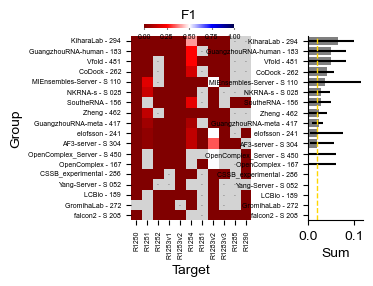

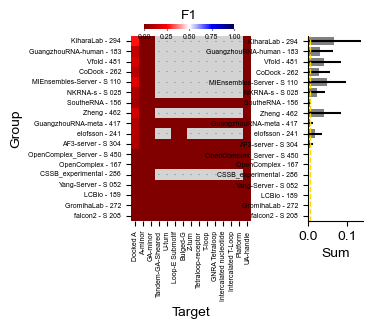

In [24]:
rank_type = 'mean'
score = 'F1'

df_summed = get_group_score(preds_top1_multimer, agg="mean", score="F1",targets_to_choose_best=[],#TARGETS_CHOOSE_BEST,
            group_col='group_target',fill_nan=np.nan,fill_not_present=0,target_col='motif_type')
df_summed[['group','target']] = df_summed.group_target.str.split('|', n=1,expand=True)
print(df_summed.target.unique())
#motif_order = df_summed.groupby('target').F1.mean().sort_values(ascending=False).index
rank_type = 'mean'
rank_order,group_score,ci = plot_heat_map(df_summed,score,
                 figsize=(3,3),
                cbar_label='',ticklabel_size=5,group_col='group',
                savefig=f'figure_subpanels/heatmap_motif_bytarget_multimer_{score}_{rank_type}',
                    rank_type=rank_type,vmin=0,vmax=1,y_text_size=5,
                     num_bootstrap=1000,target_col='target')

df_summed = get_group_score(preds_top1_multimer, agg="mean", score="F1",targets_to_choose_best=TARGETS_CHOOSE_BEST,
            group_col='group_motif',fill_nan=np.nan,fill_not_present=0,target_col='target')
df_summed[['group','motif_type']] = df_summed.group_motif.str.split('|', n=1,expand=True)
motif_order = ['DOCKED_A','A_MINOR','GA_MINOR','TANDEM_GA_SHEARED','U_TURN',
              'LOOP_E_SUBMOTIF','BULGED_G','Z_TURN','TL_RECEPTOR',
              'T_LOOP','GNRA_TETRALOOP',
               'INTERCALATED_NT','INTERCALATED_T_LOOP', 
              'PLATFORM','UA_HANDLE' ]
motif_order = [MOTIF_TYPES[x] for x in motif_order]
order = plot_heat_map(df_summed,score,
                 figsize=(3,3),
                cbar_label='',ticklabel_size=5,group_col='group',
                savefig=f'figure_subpanels/heatmap_motif_bymotif_multimer_{score}_{rank_type}',
                    rank_type=rank_type,vmin=0,vmax=1,y_text_size=5,
                     num_bootstrap=1000,target_col='motif_type',
              target_order = motif_order,rank_order=rank_order)
plt.show()

100%|██████████| 1000/1000 [01:20<00:00, 12.47it/s]
C:\Users\racha\OneDrive\Desktop\CASP16_NA\NA_CASP_assessment\analysis\CASP16_NA_assessment.py:1247: FutureWarning: The default value of observed=False is deprecated and will change to observed=True in a future version of pandas. Specify observed=False to silence this warning and retain the current behavior
  pivot_all = df_copy.pivot_table(index=group_col, columns=target_col, values=score,
100%|██████████| 1000/1000 [00:23<00:00, 43.40it/s]
C:\Users\racha\OneDrive\Desktop\CASP16_NA\NA_CASP_assessment\analysis\CASP16_NA_assessment.py:1247: FutureWarning: The default value of observed=False is deprecated and will change to observed=True in a future version of pandas. Specify observed=False to silence this warning and retain the current behavior
  pivot_all = df_copy.pivot_table(index=group_col, columns=target_col, values=score,


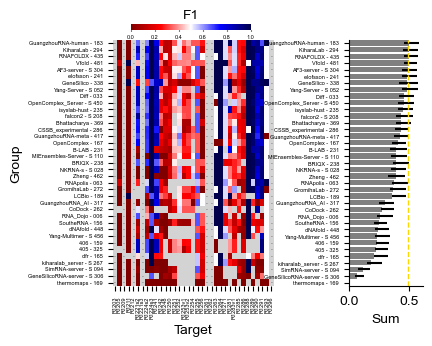

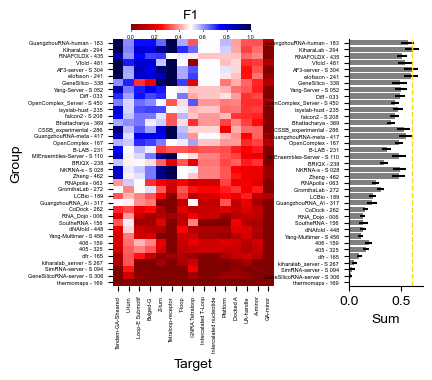

In [25]:
rank_type = 'mean'
score = 'F1'

df_summed = get_group_score(preds_top1, agg="mean", score="F1",targets_to_choose_best=TARGETS_CHOOSE_BEST,
            group_col='group_target',fill_nan=np.nan,fill_not_present=0,target_col='motif_type')
df_summed[['group','target']] = df_summed.group_target.str.split('|', n=1,expand=True)
#motif_order = df_summed.groupby('target').F1.mean().sort_values(ascending=False).index
rank_type = 'mean'
rank_order,group_score,ci = plot_heat_map(df_summed,score,
                 figsize=(4,4),
                cbar_label='',ticklabel_size=4,group_col='group',
                savefig=f'figure_subpanels/heatmap_motif_bytarget_{score}_{rank_type}',
                    rank_type=rank_type,vmin=0,vmax=1,y_text_size=4,
                     num_bootstrap=1000,target_col='target')

df_summed = get_group_score(preds_top1, agg="mean", score="F1",targets_to_choose_best=TARGETS_CHOOSE_BEST,
            group_col='group_motif',fill_nan=np.nan,fill_not_present=0,target_col='target')
df_summed[['group','motif_type']] = df_summed.group_motif.str.split('|', n=1,expand=True)
motif_order = df_summed.groupby('motif_type').F1.mean().sort_values(ascending=False).index
order = plot_heat_map(df_summed,score,
                 figsize=(4,4),
                cbar_label='',ticklabel_size=4,group_col='group',
                savefig=f'figure_subpanels/heatmap_motif_bymotif_{score}_{rank_type}',
                    rank_type=rank_type,vmin=0,vmax=1,y_text_size=4,
                     num_bootstrap=1000,target_col='motif_type',
                     target_order = motif_order,rank_order=rank_order)

plt.show()

In [26]:
df_summed = get_group_score(preds_top1, agg="mean", score="F1",targets_to_choose_best=TARGETS_CHOOSE_BEST,
            group_col='group_target',fill_nan=np.nan,fill_not_present=0,target_col='motif_type')
df_summed[['group','target']] = df_summed.group_target.str.split('|', n=1,expand=True)
df_summed.to_csv('summary_tables/motif_performance.csv')

In [27]:
df_summed = get_group_score(preds_top1, agg="mean", score="F1",targets_to_choose_best=TARGETS_CHOOSE_BEST,
            group_col='group_motif',fill_nan=np.nan,fill_not_present=0,target_col='target')
df_summed[['group','motif_type']] = df_summed.group_motif.str.split('|', n=1,expand=True)
sum_group = df_summed.groupby('group').F1.sum()
df_summed['F1_norm'] = df_summed.apply(lambda row: row.F1 * group_score.loc[row.group] / sum_group.loc[row.group], axis=1)

In [29]:
df_summed['motif_type'] = pd.Categorical(df_summed['motif_type'], categories=motif_order, ordered=True)
df_summed = df_summed.sort_values(by=['group', 'motif_type'])
df_summed.groupby('group').F1_norm.cumsum()
df_summed['cumsum_F1_norm'] = df_summed.groupby('group')['F1_norm'].cumsum()

C:\Users\racha\AppData\Local\Temp\ipykernel_23024\1168318467.py:15: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  t=ax.set_yticklabels(labels=ax.get_yticklabels(),size=6)


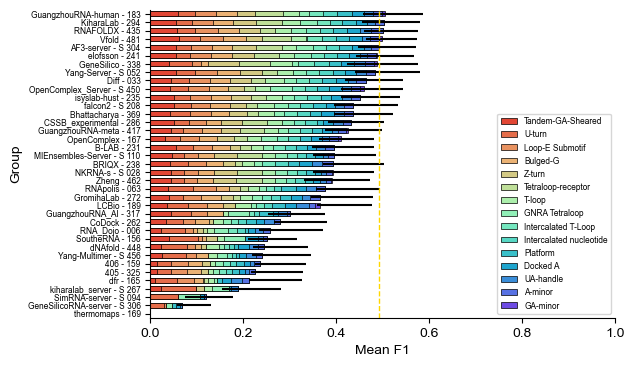

In [30]:
fig,ax = plt.subplots(1,1,figsize= (6,4))
ax.barh(rank_order,width=group_score[score], #reindex(rank_order)
            color='grey',xerr=ci,alpha=0)
sns.barplot(df_summed,x='cumsum_F1_norm',y='group',dodge=False,#order=rank_order[::-1],
                hue='motif_type',hue_order=motif_order[::-1],palette='rainbow',legend=True,
                linewidth=0.5, edgecolor="black",width=0.6,ax=ax)
handles, labels = ax.get_legend_handles_labels()
legend = ax.legend(handles[::-1], labels[::-1], title=None, loc='lower right', fontsize=6)

ax.spines['right'].set_visible(False)
ax.spines['top'].set_visible(False)
ax.set_xlabel("Mean F1",size=10)
ax.set_ylabel("Group",size=10)
ax.set_xlim(0,1)
t=ax.set_yticklabels(labels=ax.get_yticklabels(),size=6)
# Plot AF3 baseline
x_coord = group_score[score]['AF3-server - S 304'] 
ax.axvline(x=x_coord, color='gold', linestyle='--', linewidth=1, label='AF3-server - S 304')
plt.savefig('figure_subpanels/motif_barplot.png',dpi=400, bbox_inches='tight')
plt.savefig('figure_subpanels/motif_barplot.svg',dpi=400, bbox_inches='tight')
plt.show()

In [31]:
group_score.to_csv('summary_tables/motif_summ.csv',index=True)

In [32]:
preds_top1[(preds_top1.target=='R1205') & (preds_top1.motif_type=='Intercalated T-Loop')].F1.unique()

array([0.])

In [33]:
predicted[(predicted.target=='R1205')].motif_type.unique() # no T-loops predicted

array(['U_TURN', 'GA_MINOR', 'A_MINOR', 'UA_HANDLE', 'PLATFORM'],
      dtype=object)

In [34]:
preds_top1[(preds_top1.target=='R1205')].motif_type.unique()

array(['A-minor', 'Bulged-G', 'Docked A', 'GA-minor', 'GNRA Tetraloop',
       'Intercalated T-Loop', 'Intercalated nucleotide',
       'Loop-E Submotif', 'Platform', 'T-loop', 'Tandem-GA-Sheared',
       'Tetraloop-receptor', 'U-turn', 'UA-handle', 'Z-turn'],
      dtype=object)

In [35]:
native_motifs['Intercalated T-Loop']

{'R1203v1': [[['0:g111',
    '0:u112',
    '0:u113',
    '0:c114',
    '0:a115',
    '0:a116',
    '0:c119',
    '0:g18']]],
 'R1203v2': [[['0:g111',
    '0:u112',
    '0:u113',
    '0:c114',
    '0:a115',
    '0:a116',
    '0:c119',
    '0:g18']]],
 'R1205': [[['0:u24',
    '0:u25',
    '0:g26',
    '0:g27',
    '0:a28',
    '0:a29',
    '0:a31',
    '0:a5']]],
 'R1221s2': [[['2:c56',
    '2:u57',
    '2:g58',
    '2:a59',
    '2:g60',
    '2:a61',
    '2:g63',
    '2:a261']]],
 'R1241': [[['1:g31',
    '1:u32',
    '1:g33',
    '1:a34',
    '1:g35',
    '1:a36',
    '1:c39',
    '1:a246']]],
 'R1242': [[['0:u20',
    '0:u21',
    '0:g22',
    '0:a23',
    '0:a24',
    '0:a25',
    '0:a188',
    '0:a185']]],
 'R1253v1': [[['0:u135',
    '0:g136',
    '0:c137',
    '0:a138',
    '0:a139',
    '0:u140',
    '0:c142',
    '0:a335']]],
 'R1253v2': [[['0:u135',
    '0:g136',
    '0:c137',
    '0:a138',
    '0:a139',
    '0:u140',
    '0:c142',
    '0:a335']]],
 'R1271': [[['0:g54',
    '0:

In [42]:
native_motifs_o

{'A-minor': {'R1250': [[]],
  'R1251': [[['0:a34', '6:a589', '6:u603'],
    ['0:a35', '6:g604', '6:u588'],
    ['0:a447', '6:a682', '6:u669'],
    ['0:a448', '6:g670', '6:u681'],
    ['0:a764', '7:a688', '7:u646'],
    ['1:a34', '0:a589', '0:u603'],
    ['1:a35', '0:g604', '0:u588'],
    ['1:a447', '0:a682', '0:u669'],
    ['1:a448', '0:g670', '0:u681'],
    ['1:a764', '8:a688', '8:u646'],
    ['2:a34', '1:a589', '1:u603'],
    ['2:a35', '1:g604', '1:u588'],
    ['2:a447', '1:a682', '1:u669'],
    ['2:a448', '1:g670', '1:u681'],
    ['2:a764', '9:a688', '9:u646'],
    ['3:a34', '2:a589', '2:u603'],
    ['3:a35', '2:g604', '2:u588'],
    ['3:a447', '2:a682', '2:u669'],
    ['3:a448', '2:g670', '2:u681'],
    ['3:a764', 'a:a688', 'a:u646'],
    ['4:a34', '3:a589', '3:u603'],
    ['4:a35', '3:g604', '3:u588'],
    ['4:a447', '3:a682', '3:u669'],
    ['4:a448', '3:g670', '3:u681'],
    ['4:a764', 'b:a688', 'b:u646'],
    ['5:a34', '4:a589', '4:u603'],
    ['5:a35', '4:g604', '4:u588'],
   